In [212]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


In [ ]:
base_dir = Path("classified_datasets/weather")

# 1) Iterate through files and read with pandas
csv_files = sorted(base_dir.rglob("*.csv"))

dataframes = {}

for fp in csv_files:
    try:
        df = pd.read_csv(fp)
        dataframes[str(fp)] = df
    except Exception as e:
        print(f"Failed: {fp.name} -> {e}")

combined_df = pd.concat(dataframes.values(), ignore_index=True) if dataframes else pd.DataFrame()
print("Combined shape:", combined_df.shape)

Combined shape: (84923, 12)


In [214]:
df = combined_df.copy()

In [215]:
missing_percentages = df.isnull().mean() * 100
columns_to_drop = missing_percentages[missing_percentages > 70].index
df = df.drop(columns=columns_to_drop)

In [216]:
df.drop_duplicates(inplace=True)

standardizing the time to the nearest 5 minutes as some data as at 13:04, 13:09 and not 13:05, 13:10 leading to difficulties in understanding if there are missing time frames

In [ ]:
df['timeArray'] = pd.to_datetime(df['timeArray'])

df['timeArray'] = df['timeArray'].dt.floor('5min')
df

,timeArray,dAvgWS,dBaro,dDP,dGustWS,dHum,dRainSpd,dRainT,dSolar,dTemp,dWindDir
0,2018-09-01 00:45:00,1.4,1023.2,11.95,4.0,88.5,0.0,0.0,0.0,13.85,209.0
1,2018-09-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-09-01 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-09-01 01:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-09-01 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
84903,2018-12-01 22:20:00,0.0,996.2,9.60,3.2,91.0,0.3,7.6,0.0,11.00,171.0
84904,2018-12-01 22:25:00,0.0,996.2,9.80,3.2,92.0,0.3,7.6,0.0,11.00,171.0
84905,2018-12-01 22:30:00,0.0,996.2,9.80,0.0,92.0,0.3,7.6,0.0,11.00,171.0
84906,2018-12-01 22:35:00,0.0,996.2,9.70,3.2,92.0,0.3,7.6,0.0,10.90,171.0


In [ ]:
df.drop_duplicates(subset="timeArray",inplace=True)
df.reset_index(drop=True, inplace=True)

In [219]:
df.isna().sum()

timeArray       0
dAvgWS       1969
dBaro        1969
dDP          1969
dGustWS      1969
dHum         1969
dRainSpd     1969
dRainT       1969
dSolar       1969
dTemp        1969
dWindDir     1969
dtype: int64

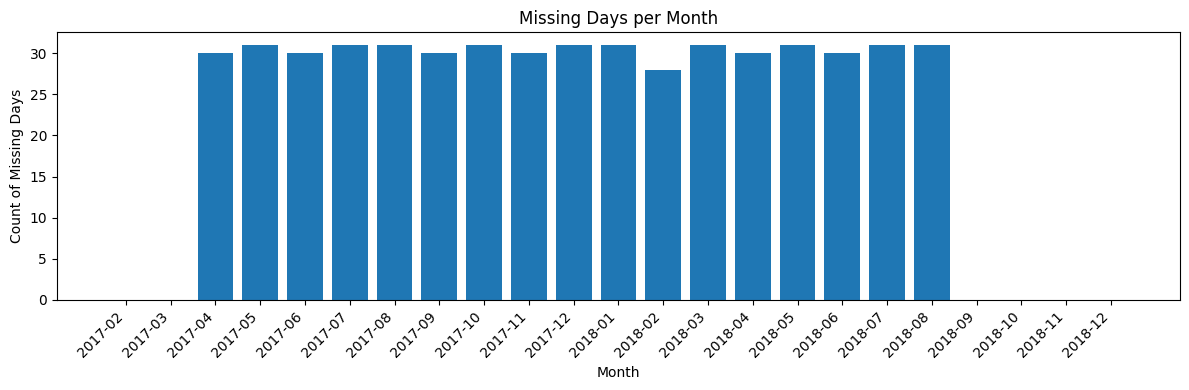

In [220]:
present_days = pd.to_datetime(df["timeArray"].dt.normalize().unique())
present_days = pd.DatetimeIndex(present_days).sort_values()

# full day range from min to max day
all_days = pd.date_range(
    start=present_days.min(),
    end=present_days.max(),
    freq='D'
)

day_status = pd.Series(False, index=all_days, name='present')
day_status.loc[present_days] = True
monthly_missing = (~day_status).resample('MS').sum()

plot_df = monthly_missing.rename('missing_days').reset_index()
plot_df.columns = ['month', 'missing_days']
plot_df['month_label'] = plot_df['month'].dt.strftime('%Y-%m')

plt.figure(figsize=(12, 4))
plt.bar(plot_df['month_label'], plot_df['missing_days'])
plt.title('Missing Days per Month')
plt.ylabel('Count of Missing Days')
plt.xlabel('Month')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

detecting if there is a 5 minute gap in the data, excluding the large holes

In [221]:
df = df.interpolate("linear")

In [222]:
df = df.sort_values("timeArray").reset_index(drop=True)

In [ ]:
df["timeArray"] = pd.to_datetime(df["timeArray"])
df['gap_size'] = df['timeArray'].diff()

# 2. Define your thresholds (e.g., 3 periods = 15 mins)
small_gap_limit = pd.Timedelta(minutes=15) 
medium_gap_limit = pd.Timedelta(hours=2)

# 3. View the distribution of gaps (excluding the 6-month abyss)
gaps_summary = df[(df['gap_size'] > pd.Timedelta(minutes=5)) & 
                  (df['gap_size'] < pd.Timedelta(days=1))]

print(gaps_summary['gap_size'].value_counts())

gap_size
0 days 00:10:00    844
0 days 00:15:00    206
0 days 00:25:00      1
0 days 02:35:00      1
0 days 01:05:00      1
Name: count, dtype: int64


In [ ]:
df = df.set_index('timeArray').sort_index()

# 2. Resample to create the 5-minute grid
# This inserts NaNs for all gaps (small and large)
df_filled_gaps = df.resample('5min').asfreq()

# 3. Interpolate with a 24-hour limit
# This fills the 10/15/25 min gaps, but stops after 288 rows (5 hours)
df_interpolated = df_filled_gaps.interpolate(method='linear', limit=60)

# 4. Optional: Drop the remaining NaNs (the year 2018)
# This removes the missing year entirely from your dataframe (2018)
df_final = df_interpolated.dropna()

In [ ]:
df_final.drop(columns=["gap_size"], inplace=True)
df_final

,dAvgWS,dBaro,dDP,dGustWS,dHum,dRainSpd,dRainT,dSolar,dTemp,dWindDir
timeArray,,,,,,,,,,
2017-02-01 00:05:00,0.0,1008.7,9.500000,0.000000,96.000000,2.300000,0.3,0.0,10.1,278.000000
2017-02-01 00:10:00,0.0,1008.7,9.400000,0.000000,96.000000,2.300000,0.3,0.0,10.1,278.000000
2017-02-01 00:15:00,0.0,1008.7,9.400000,0.000000,96.000000,2.000000,0.5,0.0,10.0,278.000000
2017-02-01 00:20:00,0.0,1008.7,9.400000,0.000000,96.000000,2.000000,0.5,0.0,10.1,278.000000
2017-02-01 00:25:00,0.0,1008.7,9.400000,0.000000,96.000000,2.000000,0.8,0.0,10.1,278.000000
...,...,...,...,...,...,...,...,...,...,...
2018-12-01 23:35:00,9.7,995.5,11.600000,17.700000,94.000000,0.500000,8.1,0.0,12.5,219.000000
2018-12-01 23:40:00,13.0,995.1,11.800000,16.100000,94.000000,0.500000,8.1,0.0,12.7,241.000000
2018-12-01 23:45:00,9.6,995.1,11.766667,17.166667,93.333333,0.266667,8.1,0.0,12.8,236.333333
